# 📊 E-Commerce Sales Analysis

## End-to-End Data Analysis using Python, SQL and RFM Customer Segmentation

**This project analyzes e-commerce sales data to uncover insights related to sales performance, customers, products, regions, and customer purchasing behavior.**

---

# 📂 1. Data Loading & Understanding

In this section, the three datasets are loaded and explored to understand their structure, columns, data types, and overall quality.

**Datasets used:**
- 👤 Customers
- 🛒 Orders
- 📦 **Products**

---

# 🧹 2. Data Cleaning & Preparation

This section focuses on checking and improving data quality before performing the analysis.

**Steps performed:**
- Checked data types and dataset information
- Checked for missing values
- Converted date columns to datetime format
- Identified duplicate records
- Removed duplicate rows from the orders dataset
- Validated customer, product, and order IDs

---

# 📊 3. Business KPI Analysis

This section calculates the key performance indicators (KPIs) used to measure overall e-commerce business performance.

**KPIs calculated:**
- 💰 Total Revenue
- 🛒 Total Orders
- 👥 Total Customers
- 💳 Average Order Value

---

# 📈 4. Exploratory Data Analysis (EDA)

This section explores sales trends and business performance across different dimensions.

**Analysis includes:**
- 📅 Monthly revenue trends
- 🛍️ Revenue by product category
- 🌍 Revenue by region
- 👥 Revenue by customer segment
- 🏆 Top 10 products by revenue
- 💰 Top 10 customers by revenue

##Upload the CSV **files**

In [67]:
import pandas as pd

# Load datasets
customers = pd.read_csv("/content/customers(1).csv")
orders = pd.read_csv("/content/orders(1).csv")
products = pd.read_csv("/content/products(1).csv")

# Display dataset dimensions
print("Customers dataset shape:", customers.shape)
print("Orders dataset shape:", orders.shape)
print("Products dataset shape:", products.shape)

Customers dataset shape: (400, 7)
Orders dataset shape: (2539, 8)
Products dataset shape: (100, 5)


##Check the **data**

In [70]:
# Preview the first five rows of each dataset

print("CUSTOMERS DATASET")
display(customers.head())

print("ORDERS DATASET")
display(orders.head())

print("PRODUCTS DATASET")
display(products.head())

CUSTOMERS DATASET


,customer_id,customer_name,email,city,signup_date,region,segment
0,1,Akash Mishra,customer1@example.com,Jaipur,2024-09-09,North,Consumer
1,2,Vikram Iyer,customer2@example.com,Chennai,2025-03-28,South,Corporate
2,3,Arjun Shah,customer3@example.com,Delhi,2025-04-13,North,Home Office
3,4,Vikram Kumar,customer4@example.com,Lucknow,2025-11-20,North,Consumer
4,5,Sneha Singh,customer5@example.com,Delhi,2024-02-16,North,Consumer


ORDERS DATASET


,order_id,customer_id,product_id,order_date,quantity,unit_price,discount,revenue
0,1,283,87,2024-03-01,1,2175.83,0.15,1849.46
1,1,283,22,2024-03-01,1,7167.91,0.00,7167.91
2,2,87,19,2024-02-11,3,3171.34,0.00,9514.02
3,2,87,75,2024-02-11,2,44807.59,0.00,89615.18
4,3,33,87,2024-08-27,2,2175.83,0.05,4134.08


PRODUCTS DATASET


,product_id,product_name,category,price,stock_quantity
0,1,Laptop,Electronics,57994.93,78
1,2,Wireless Mouse,Electronics,826.86,19
2,3,Keyboard,Electronics,2625.01,47
3,4,Headphones,Electronics,6232.39,21
4,5,Smartphone,Electronics,60993.48,19


##Check data types and missing **values**

In [71]:
# Display dataset information

print("========== CUSTOMERS DATASET INFO ==========")
customers.info()

print("\n========== ORDERS DATASET INFO ==========")
orders.info()

print("\n========== PRODUCTS DATASET INFO ==========")
products.info()


# Check missing values

print("\n========== MISSING VALUES ==========")

print("\nCustomers:")
print(customers.isnull().sum())

print("\nOrders:")
print(orders.isnull().sum())

print("\nProducts:")
print(products.isnull().sum())

========== CUSTOMERS DATASET INFO ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customer_id    400 non-null    int64 
 1   customer_name  400 non-null    object
 2   email          400 non-null    object
 3   city           400 non-null    object
 4   signup_date    400 non-null    object
 5   region         400 non-null    object
 6   segment        400 non-null    object
dtypes: int64(1), object(6)
memory usage: 22.0+ KB

========== ORDERS DATASET INFO ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2539 entries, 0 to 2538
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   order_id     2539 non-null   int64  
 1   customer_id  2539 non-null   int64  
 2   product_id   2539 non-null   int64  
 3   order_date   2539 non-null   object 
 4   quantit

##Convert date **columns**

In [73]:
# Convert date columns to datetime format

customers["signup_date"] = pd.to_datetime(customers["signup_date"])
orders["order_date"] = pd.to_datetime(orders["order_date"])

# Verify the updated data types

print("Customers signup_date type:", customers["signup_date"].dtype)
print("Orders order_date type:", orders["order_date"].dtype)

Customers signup_date type: datetime64[ns]
Orders order_date type: datetime64[ns]


##Check duplicates and ID **consistency**

In [75]:
# Check duplicate rows

print("========== DUPLICATE ROWS ==========")

print("Customers:", customers.duplicated().sum())
print("Orders:", orders.duplicated().sum())
print("Products:", products.duplicated().sum())


# Validate unique IDs

print("\n========== UNIQUE ID VALIDATION ==========")

print("\nCustomers:")
print("Unique Customer IDs:", customers["customer_id"].nunique())
print("Total Customer Records:", len(customers))

print("\nProducts:")
print("Unique Product IDs:", products["product_id"].nunique())
print("Total Product Records:", len(products))

print("\nOrders:")
print("Unique Order IDs:", orders["order_id"].nunique())
print("Total Order Records:", len(orders))

========== DUPLICATE ROWS ==========
Customers: 0
Orders: 2
Products: 0

========== UNIQUE ID VALIDATION ==========

Customers:
Unique Customer IDs: 400
Total Customer Records: 400

Products:
Unique Product IDs: 100
Total Product Records: 100

Orders:
Unique Order IDs: 1253
Total Order Records: 2539


#View duplicate order **records**

In [77]:
# Display all duplicate rows in the orders dataset

duplicates = orders[orders.duplicated(keep=False)]

print("Duplicate order rows:")
display(duplicates)

Duplicate order rows:


,order_id,customer_id,product_id,order_date,quantity,unit_price,discount,revenue
204,101,264,73,2025-04-25,1,18192.18,0.0,18192.18
205,101,264,73,2025-04-25,1,18192.18,0.0,18192.18
1877,927,39,21,2025-07-29,1,4472.70,0.1,4025.43
1878,927,39,21,2025-07-29,1,4472.70,0.1,4025.43


#Remove duplicate **rows**

In [79]:
# Remove duplicate rows from the orders dataset

orders = orders.drop_duplicates()

# Verify the cleaned dataset

print("Orders dataset shape after removing duplicates:", orders.shape)
print("Duplicate rows remaining:", orders.duplicated().sum())

Orders dataset shape after removing duplicates: (2537, 8)
Duplicate rows remaining: 0


#Overall Business **KPIs**

In [81]:
# Calculate key business KPIs

total_revenue = orders["revenue"].sum()
total_orders = orders["order_id"].nunique()
total_customers = customers["customer_id"].nunique()

# Calculate Average Order Value
average_order_value = total_revenue / total_orders


# Display KPIs

print("📊 E-COMMERCE BUSINESS KPIs")
print("=" * 35)

print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Average Order Value: ₹{average_order_value:,.2f}")

📊 E-COMMERCE BUSINESS KPIs
Total Revenue: ₹40,299,250.84
Total Orders: 1,253
Total Customers: 400
Average Order Value: ₹32,162.21


#Monthly Revenue **Trend**

,month,revenue
0,2024-01,1644989.32
1,2024-02,1200353.17
2,2024-03,998747.85
3,2024-04,1602572.21
4,2024-05,1171873.08
5,2024-06,1638651.44
6,2024-07,1421366.49
7,2024-08,2124443.69
8,2024-09,1795163.80
9,2024-10,2119048.12


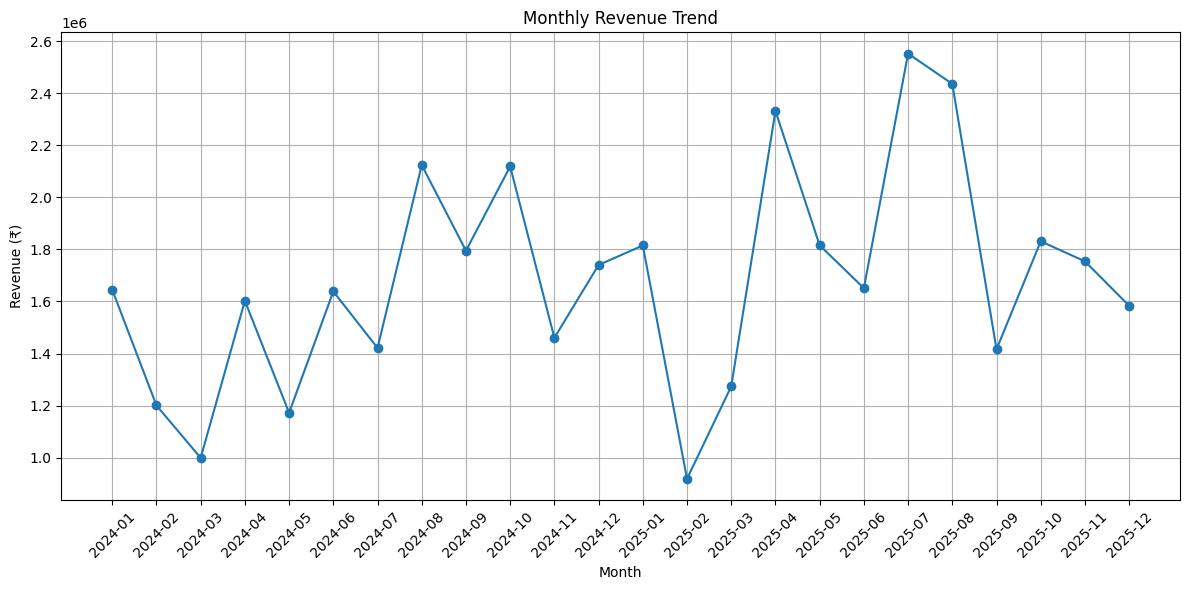

In [82]:
import matplotlib.pyplot as plt

# Create a month column from the order date
orders["month"] = orders["order_date"].dt.to_period("M").astype(str)

# Calculate monthly revenue
monthly_revenue = (
    orders.groupby("month")["revenue"]
    .sum()
    .reset_index()
)

# Display monthly revenue data
display(monthly_revenue)

# Create visualization
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue["month"],
    monthly_revenue["revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

##Category Revenue **Analysis**

,category,revenue
0,Furniture,19593602.18
1,Electronics,16078217.04
2,Footwear,2104549.39
3,Home & Kitchen,1706960.81
4,Accessories,548847.09
5,Office Supplies,267074.33


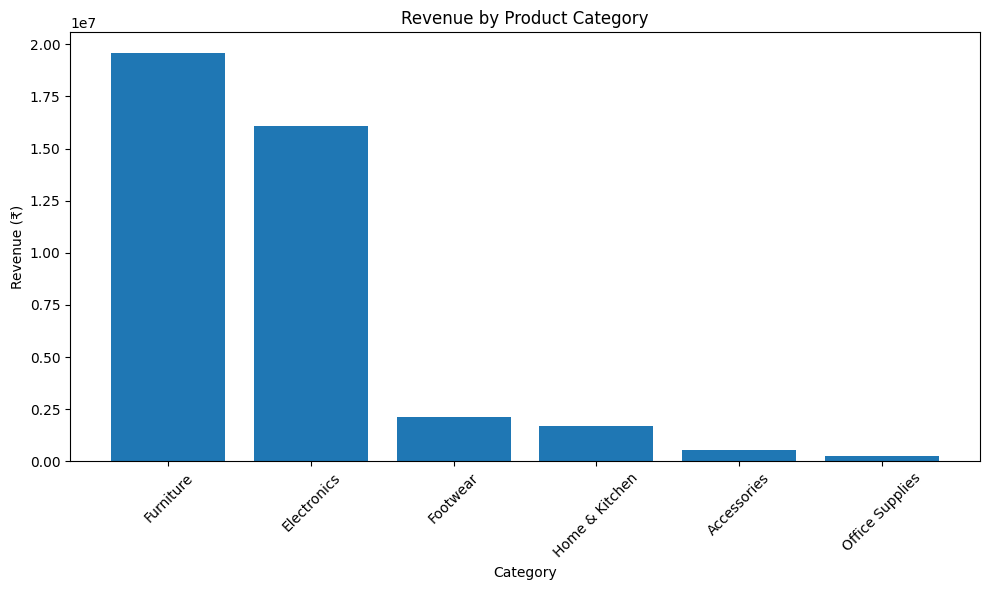

In [83]:
# Category-wise Revenue Analysis

# Merge orders with products
category_sales = orders.merge(
    products[["product_id", "category"]],
    on="product_id",
    how="left"
)

# Calculate revenue by category
category_revenue = (
    category_sales.groupby("category")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# Display category revenue
display(category_revenue)

# Visualization
plt.figure(figsize=(10, 6))

plt.bar(
    category_revenue["category"],
    category_revenue["revenue"]
)

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#Regional Revenue **Analysis**

,region,revenue
0,North,22860185.69
1,South,9697995.75
2,West,3967719.27
3,East,3773350.13


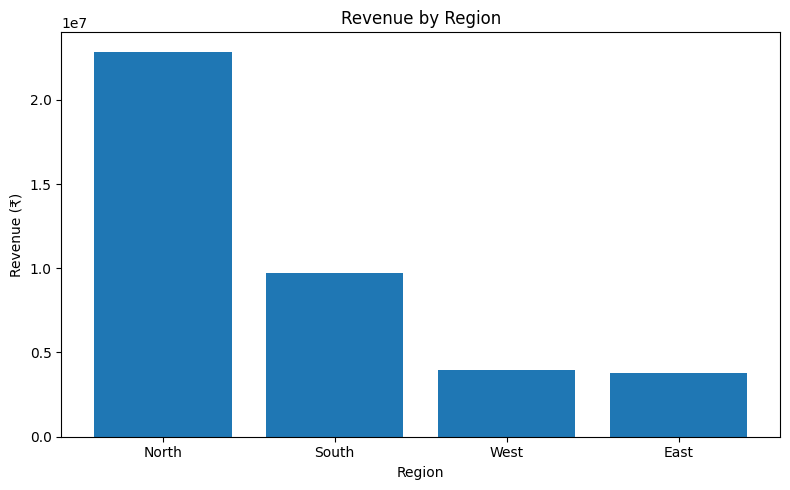

In [85]:
# Region-wise Revenue Analysis

# Merge orders with customer region information
region_sales = orders.merge(
    customers[["customer_id", "region"]],
    on="customer_id",
    how="left"
)

# Calculate revenue by region
region_revenue = (
    region_sales.groupby("region")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# Display region-wise revenue
display(region_revenue)

# Visualization
plt.figure(figsize=(8, 5))

plt.bar(
    region_revenue["region"],
    region_revenue["revenue"]
)

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue (₹)")

plt.tight_layout()
plt.show()

#Top 10 Products by **Revenue**

,product_name,category,revenue
0,Wardrobe,Furniture,4720479.55
1,Smart TV,Electronics,3689779.02
2,Smartphone,Electronics,3147263.57
3,Sofa,Furniture,3094858.17
4,Laptop,Electronics,2885247.77
5,Office Chair,Furniture,1764807.36
6,Dining Table,Furniture,1762803.17
7,Recliner,Furniture,1602731.03
8,Storage Cabinet,Furniture,1403487.17
9,Office Desk,Furniture,1396308.81


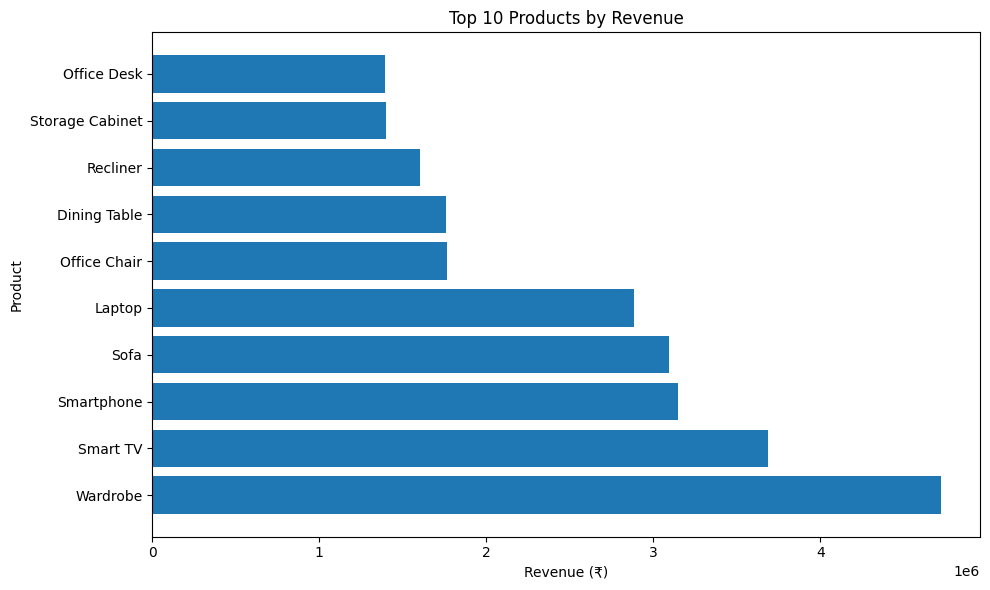

In [86]:
# Top 10 Products by Revenue

# Merge orders with product information
product_sales = orders.merge(
    products[["product_id", "product_name", "category"]],
    on="product_id",
    how="left"
)

# Calculate revenue by product
top_products = (
    product_sales.groupby(["product_name", "category"])["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# Display top products
display(top_products)

# Visualization
plt.figure(figsize=(10, 6))

plt.barh(
    top_products["product_name"],
    top_products["revenue"]
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (₹)")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

##Customer Segment **Analysis**

,segment,total_revenue,total_orders,average_order_value
0,Consumer,21726258.24,1392,15607.944138
1,Corporate,10908301.06,676,16136.540030
2,Home Office,7664691.54,469,16342.625885


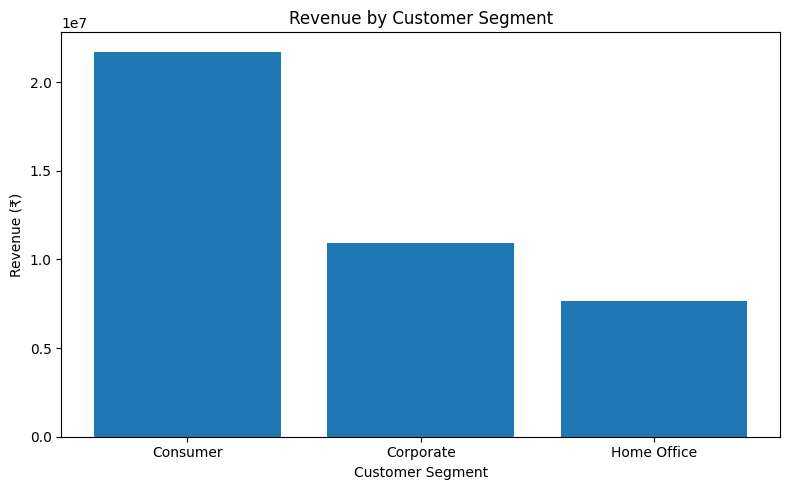

In [87]:
# Customer Segment Analysis

# Merge orders with customer segment information
segment_sales = orders.merge(
    customers[["customer_id", "segment"]],
    on="customer_id",
    how="left"
)

# Calculate performance metrics by customer segment
segment_revenue = (
    segment_sales.groupby("segment")["revenue"]
    .agg(
        total_revenue="sum",
        total_orders="count",
        average_order_value="mean"
    )
    .sort_values("total_revenue", ascending=False)
    .reset_index()
)

# Display customer segment analysis
display(segment_revenue)

# Visualization
plt.figure(figsize=(8, 5))

plt.bar(
    segment_revenue["segment"],
    segment_revenue["total_revenue"]
)

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue (₹)")

plt.tight_layout()
plt.show()

#Top Customers by **Revenue**

,customer_id,customer_name,region,segment,revenue
0,187,Priya Singh,West,Consumer,507558.51
1,210,Arjun Gupta,South,Home Office,414552.57
2,330,Shreya Patel,North,Consumer,398699.97
3,343,Aditi Patel,East,Corporate,379434.50
4,206,Varun Gupta,North,Consumer,362260.15
5,373,Vikram Das,North,Corporate,362203.71
6,115,Riya Mehta,North,Consumer,352077.75
7,144,Rahul Reddy,North,Consumer,346610.31
8,154,Nandini Patel,North,Consumer,342428.81
9,76,Nandini Singh,South,Corporate,324689.87


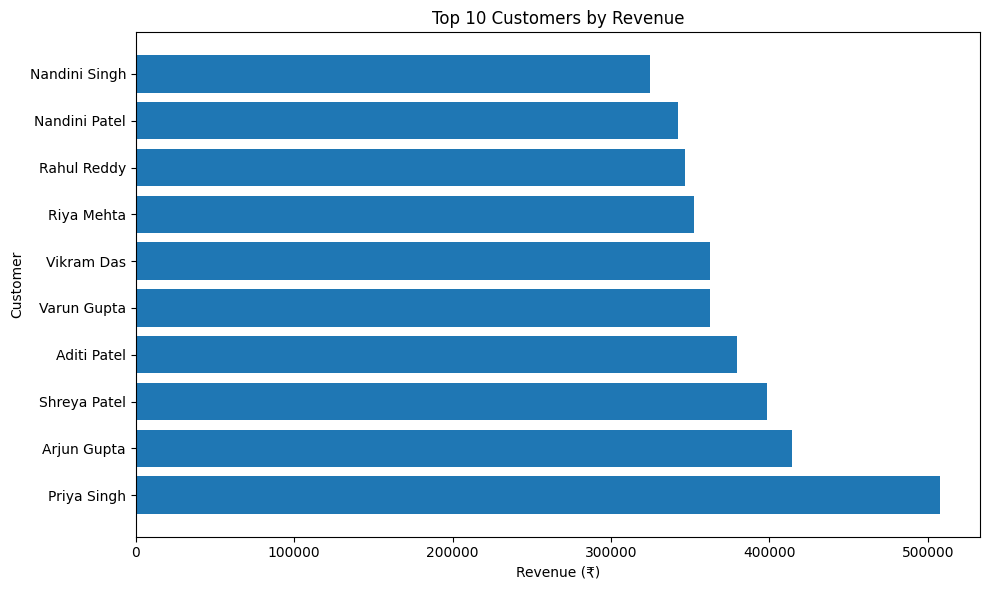

In [88]:
# Top 10 Customers by Revenue

# Merge orders with customer information
customer_sales = orders.merge(
    customers[["customer_id", "customer_name", "region", "segment"]],
    on="customer_id",
    how="left"
)

# Calculate revenue by customer
top_customers = (
    customer_sales.groupby(
        ["customer_id", "customer_name", "region", "segment"]
    )["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# Display top customers
display(top_customers)

# Visualization
plt.figure(figsize=(10, 6))

plt.barh(
    top_customers["customer_name"],
    top_customers["revenue"]
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue (₹)")
plt.ylabel("Customer")

plt.tight_layout()
plt.show()

---

# 👥 5. Customer Segmentation Using RFM Analysis

RFM analysis is used to segment customers based on their purchasing behavior.

### RFM Metrics

- **Recency:** Number of days since the customer's most recent purchase
- **Frequency:** Number of purchases made by the customer
- **Monetary:** Total revenue generated by the customer

Customers are scored based on these metrics and grouped into meaningful segments to better understand customer behavior and identify high-value customers.

**Customer segments include:**
- 🏆 Champion
- 💎 Loyal Customer
- 🌱 Potential Loyalist
- 👤 Regular Customer
- ⚠️ At Risk
- ❌ Lost Customer

In [91]:
# Find the latest order date in the dataset

latest_date = orders["order_date"].max()

print("Latest order date:", latest_date)

Latest order date: 2025-12-31 00:00:00


#calculate Recency, Frequency, and **Monetary**

In [92]:
# Calculate RFM metrics for each customer

rfm = orders.groupby("customer_id").agg(
    Recency=("order_date", lambda x: (latest_date - x.max()).days),
    Frequency=("order_id", "nunique"),
    Monetary=("revenue", "sum")
).reset_index()

# Display the first five customers
rfm.head()

,customer_id,Recency,Frequency,Monetary
0,1,139,2,43604.49
1,2,319,3,231238.02
2,3,64,6,265589.71
3,4,8,4,144407.22
4,5,163,5,61478.94


#Create RFM **Scores**

In [93]:
# Create RFM scores

# Recency: Lower number of days = better score
rfm["R_score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5, 4, 3, 2, 1],
    duplicates="drop"
)

# Frequency: More orders = better score
rfm["F_score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

# Monetary: Higher spending = better score
rfm["M_score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1, 2, 3, 4, 5],
    duplicates="drop"
)

# Display scored RFM data
rfm.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score
0,1,139,2,43604.49,3,1,2
1,2,319,3,231238.02,2,2,5
2,3,64,6,265589.71,4,5,5
3,4,8,4,144407.22,5,3,4
4,5,163,5,61478.94,3,4,2


#RFM **Segmentation**

In [94]:
# Define customer segmentation rules

def segment_customer(row):

    if row["R_score"] >= 4 and row["F_score"] >= 4 and row["M_score"] >= 4:
        return "Champion"

    elif row["F_score"] >= 4 and row["M_score"] >= 4:
        return "Loyal Customer"

    elif row["R_score"] >= 4 and row["F_score"] >= 3:
        return "Potential Loyalist"

    elif row["R_score"] <= 2 and row["F_score"] >= 3:
        return "At Risk"

    elif row["R_score"] <= 2 and row["F_score"] <= 2:
        return "Lost Customer"

    else:
        return "Regular Customer"


# Apply customer segmentation
rfm["Segment"] = rfm.apply(segment_customer, axis=1)

# Display results
rfm.head(10)

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,Segment
0,1,139,2,43604.49,3,1,2,Regular Customer
1,2,319,3,231238.02,2,2,5,Lost Customer
2,3,64,6,265589.71,4,5,5,Champion
3,4,8,4,144407.22,5,3,4,Potential Loyalist
4,5,163,5,61478.94,3,4,2,Regular Customer
5,6,386,2,24159.12,1,1,1,Lost Customer
6,7,48,1,9307.76,4,1,1,Regular Customer
7,8,66,3,260399.87,4,2,5,Regular Customer
8,9,662,1,4315.47,1,1,1,Lost Customer
9,10,66,5,78063.25,4,4,3,Potential Loyalist


#RFM Segment **Distribution**

,Segment,Customer_Count,Percentage
0,Lost Customer,91,24.33
1,Regular Customer,90,24.06
2,Champion,67,17.91
3,Potential Loyalist,50,13.37
4,Loyal Customer,40,10.70
5,At Risk,36,9.63


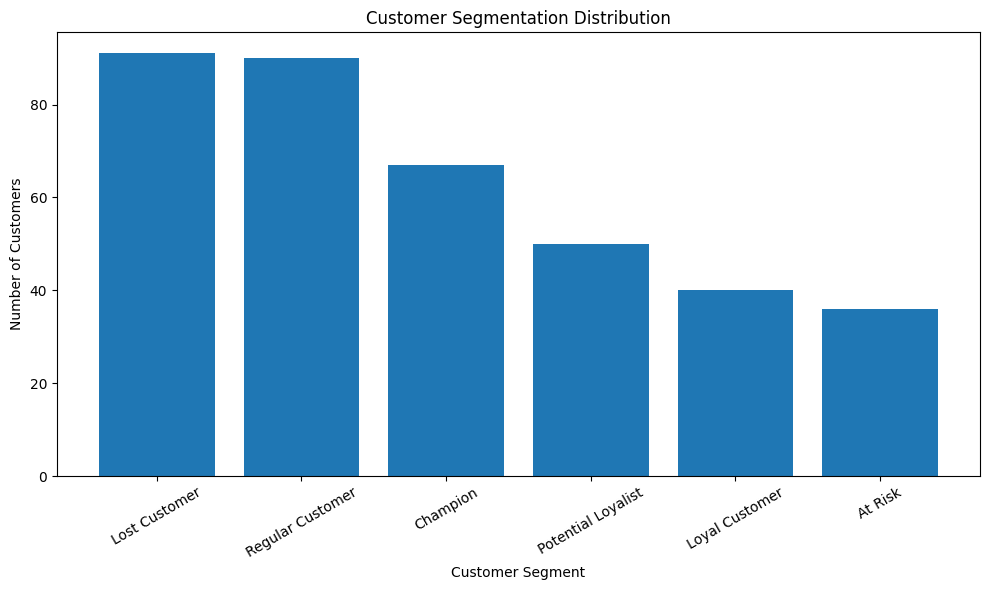

In [95]:
# Customer Segmentation Summary

# Count customers in each segment
segment_summary = (
    rfm["Segment"]
    .value_counts()
    .reset_index()
)

# Rename columns
segment_summary.columns = ["Segment", "Customer_Count"]

# Calculate percentage of customers in each segment
segment_summary["Percentage"] = (
    segment_summary["Customer_Count"] / len(rfm) * 100
).round(2)

# Display segmentation summary
display(segment_summary)


# Customer Segmentation Visualization

plt.figure(figsize=(10, 6))

plt.bar(
    segment_summary["Segment"],
    segment_summary["Customer_Count"]
)

plt.title("Customer Segmentation Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# 📌 6. Key Insights & Conclusion

## Key Insights

- Furniture generated the highest revenue among all product categories.
- The North region generated the highest overall revenue.
- The Consumer segment contributed the highest revenue.
- Wardrobe was the highest revenue-generating product.
- The analysis identified the top 10 customers contributing the most revenue.
- Monthly revenue showed fluctuations across different months.
- RFM analysis identified different customer groups, including Champions, Loyal Customers, Potential Loyalists, Regular Customers, At Risk Customers, and Lost Customers.

## Conclusion

This project demonstrates an end-to-end data analytics workflow using Python and SQL. The analysis covered data cleaning, exploratory data analysis, business KPI calculation, revenue analysis, customer analysis, data visualization, and RFM-based customer segmentation.

The insights generated from this analysis can help businesses better understand sales performance, identify high-value customers, improve customer retention strategies, and support data-driven business decisions.

## 🛠️ Technologies Used

**Python • Pandas • Matplotlib • SQL • MySQL • Google Colab • Jupyter Notebook**